In [3]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns

# Set a nice style for our plots
sns.set_style("whitegrid")

--- Analyzing Class Distribution ---
Patient count per COPD Stage:
Diagnosis
COPD4    17
COPD3     7
COPD2     7
COPD0     6
COPD1     5
Name: count, dtype: int64


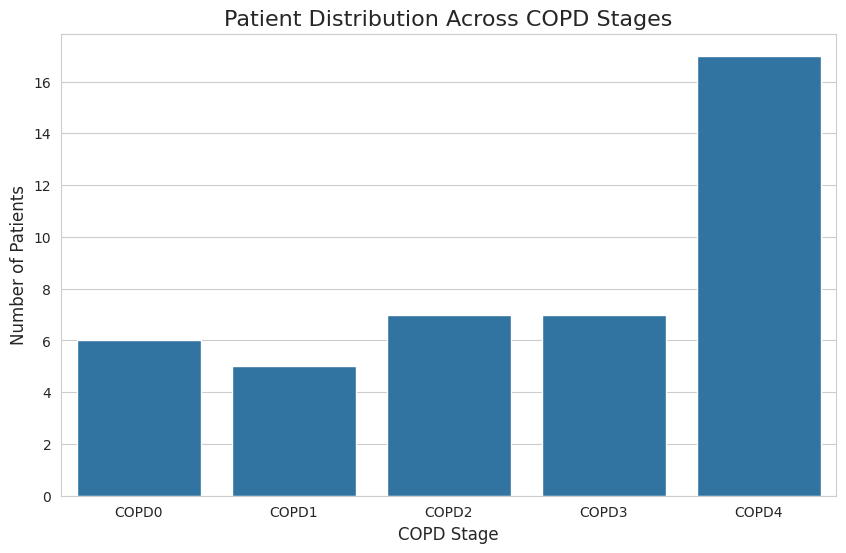

In [2]:
# --- Configuration ---
LABEL_PATH = "/home/punith/Desktop/cHEAL 2.o/Labels.xlsx"

# --- Load and Analyze Labels ---
print("--- Analyzing Class Distribution ---")
df = pd.read_excel(LABEL_PATH)

# We're interested in all COPD stages
all_classes = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4']
df_all_stages = df[df['Diagnosis'].isin(all_classes)].copy()

# Count how many patients are in each stage
class_distribution = df_all_stages['Diagnosis'].value_counts()
print("Patient count per COPD Stage:")
print(class_distribution)

# --- Visualize the Distribution ---
plt.figure(figsize=(10, 6))
sns.barplot(x=class_distribution.index, y=class_distribution.values, order=all_classes)
plt.title('Patient Distribution Across COPD Stages', fontsize=16)
plt.xlabel('COPD Stage', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.show()

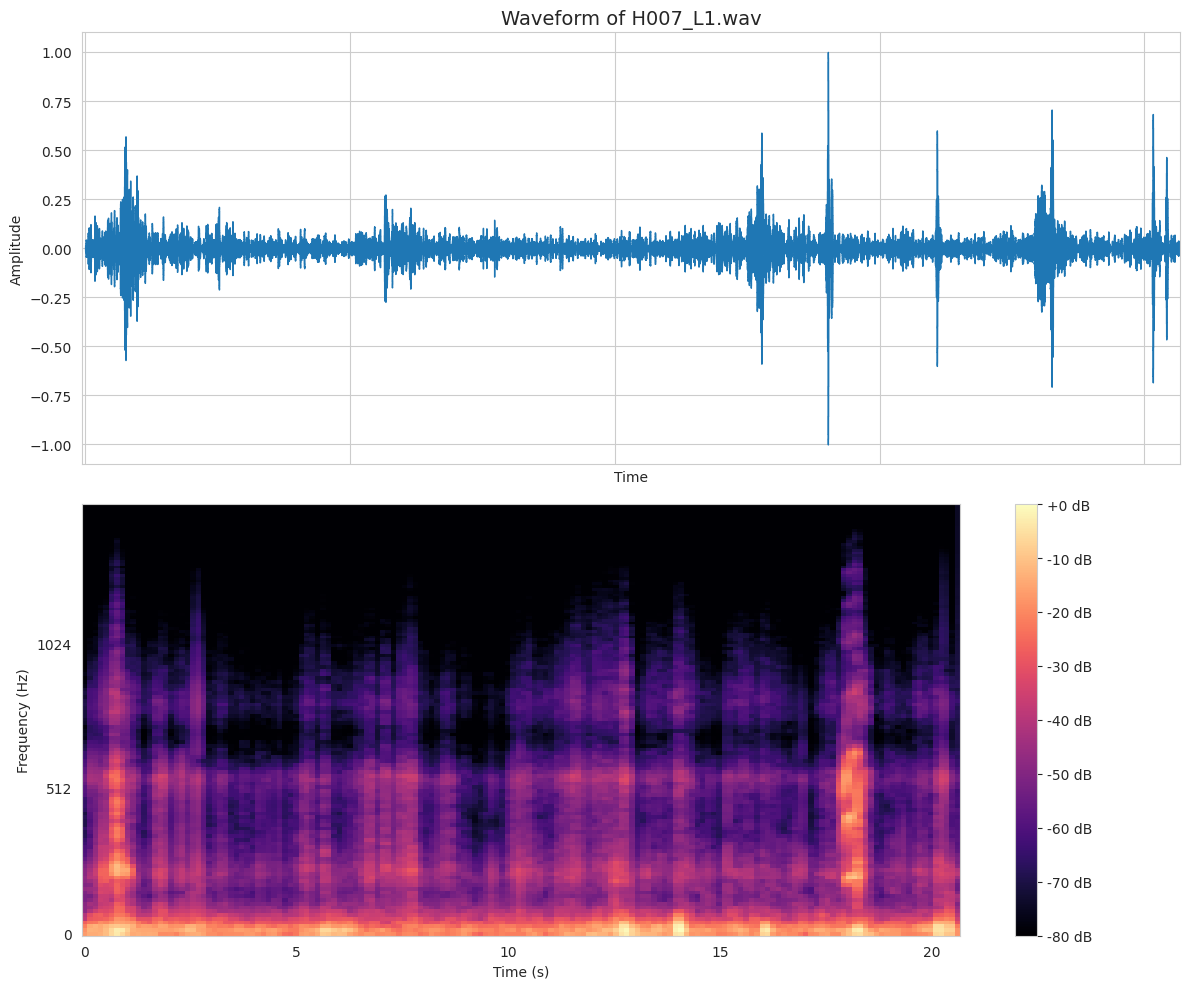

In [9]:
# --- Configuration ---
AUDIO_DIR = "./RespiratoryDatabase@TR"

# Let's pick a sample file from a more severe case to see interesting features
sample_file_path = os.path.join(AUDIO_DIR, "H007_L1.wav") # A patient from COPD3

# --- Load and Process Audio ---
try:
    y, sr = librosa.load(sample_file_path, sr=None)
    
    # Extract the Log-Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_S = librosa.power_to_db(S, ref=np.max)

    # --- Plotting ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot 1: The Waveform
    librosa.display.waveshow(y, sr=sr, ax=axs[0])
    axs[0].set_title(f'Waveform of {os.path.basename(sample_file_path)}', fontsize=14)
    axs[0].set_ylabel('Amplitude')

    # Plot 2: The Log-Mel Spectrogram
    img = librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', ax=axs[1])
    # axs[1].set_title(f'Log-Mel Spectrogram', fontsize=14)
    axs[1].set_ylabel('Frequency (Hz)')
    axs[1].set_xlabel('Time (s)')
    fig.colorbar(img, ax=axs[1], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not load or process sample file: {e}")

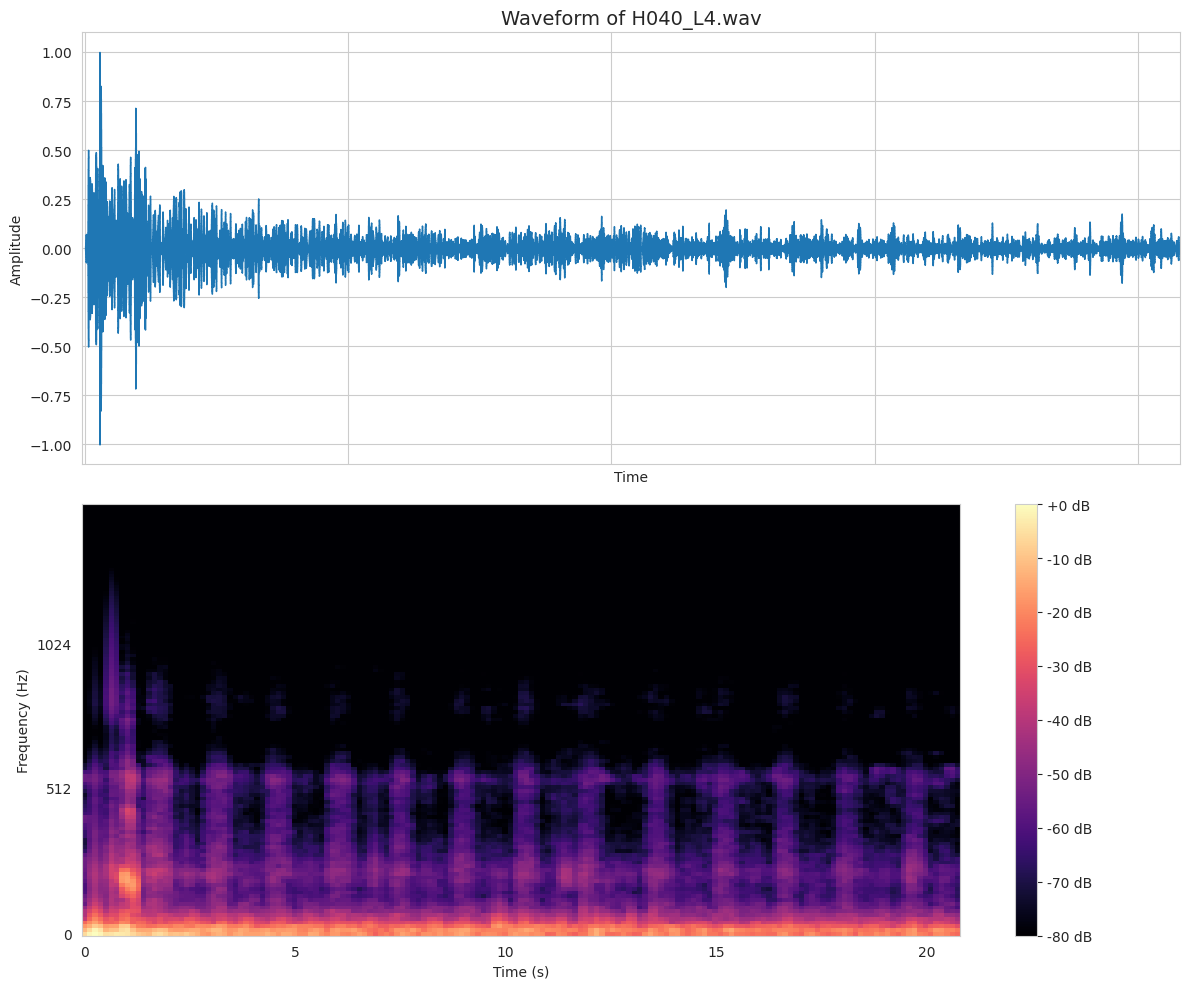

In [8]:
# --- Configuration ---
AUDIO_DIR = "./RespiratoryDatabase@TR"
import os

# Let's pick a sample file from a more severe case to see interesting features
sample_file_path = os.path.join(AUDIO_DIR, "H040_L4.wav") # A patient from COPD3

# --- Load and Process Audio ---
try:
    y, sr = librosa.load(sample_file_path, sr=None)
    
    # Extract the Log-Mel Spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
    log_S = librosa.power_to_db(S, ref=np.max)

    # --- Plotting ---
    fig, axs = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

    # Plot 1: The Waveform
    librosa.display.waveshow(y, sr=sr, ax=axs[0])
    axs[0].set_title(f'Waveform of {os.path.basename(sample_file_path)}', fontsize=14)
    axs[0].set_ylabel('Amplitude')

    # Plot 2: The Log-Mel Spectrogram
    img = librosa.display.specshow(log_S, sr=sr, x_axis='time', y_axis='mel', ax=axs[1])
    # axs[1].set_title(f'Log-Mel Spectrogram', fontsize=14)
    axs[1].set_ylabel('Frequency (Hz)')
    axs[1].set_xlabel('Time (s)')
    fig.colorbar(img, ax=axs[1], format='%+2.0f dB')
    
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not load or process sample file: {e}")

Saving normalization statistics...
📊 Total audio samples: 1200
📊 Total labels: 1200
🧪 Unique classes: (array([0, 1, 2, 3, 4]), array([240, 240, 240, 240, 240]))
Epoch 1/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.2635 - loss: 3.0870
Epoch 1: val_accuracy improved from -inf to 0.16146, saving model to best_copd_model_finetuned.h5


✅ Finished epoch 1 — val_acc: 0.1615
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - accuracy: 0.2633 - loss: 3.0715 - val_accuracy: 0.1615 - val_loss: 3.4271 - learning_rate: 0.0012
Epoch 2/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.3270 - loss: 1.5071
Epoch 2: val_accuracy improved from 0.16146 to 0.37500, saving model to best_copd_model_finetuned.h5


✅ Finished epoch 2 — val_acc: 0.3750
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 50ms/step - accuracy: 0.3274 - loss: 1.5068 - val_accuracy: 0.3750 - val_loss: 1.6378 - learning_rate: 0.0012
Epoch 3/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.4464 - loss: 1.3063
Epoch 3: val_accuracy improved from 0.37500 to 0.46875, saving model to best_copd_model_finetuned.h5


✅ Finished epoch 3 — val_acc: 0.4688
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - accuracy: 0.4464 - loss: 1.3063 - val_accuracy: 0.4688 - val_loss: 1.3325 - learning_rate: 0.0012
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5772 - loss: 1.0869
Epoch 4: val_accuracy improved from 0.46875 to 0.57812, saving model to best_copd_model_finetuned.h5


✅ Finished epoch 4 — val_acc: 0.5781
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - accuracy: 0.5770 - loss: 1.0870 - val_accuracy: 0.5781 - val_loss: 1.0540 - learning_rate: 0.0012
Epoch 5/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5273 - loss: 1.0322
Epoch 5: val_accuracy improved from 0.57812 to 0.70312, saving model to best_copd_model_finetuned.h5


...

✅ Finished epoch 15 — val_acc: 0.9271
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9041 - loss: 0.2480 - val_accuracy: 0.9271 - val_loss: 0.2625 - learning_rate: 4.8000e-04
Epoch 16/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9007 - loss: 0.1993
Epoch 16: ReduceLROnPlateau reducing learning rate to 0.00019200000679120421.

Epoch 16: val_accuracy improved from 0.92708 to 0.93229, saving model to best_copd_model_finetuned.h5


✅ Finished epoch 16 — val_acc: 0.9323
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9009 - loss: 0.1994 - val_accuracy: 0.9323 - val_loss: 0.2740 - learning_rate: 4.8000e-04
Epoch 17/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9129 - loss: 0.2108
Epoch 17: val_accuracy did not improve from 0.93229
✅ Finished epoch 17 — val_acc: 0.9271
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.9130 - loss: 0.2106 - val_accuracy: 0.9271 - val_loss: 0.2339 - learning_rate: 1.9200e-04
Epoch 18/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9415 - loss: 0.1566
Epoch 18: val_accuracy did not improve from 0.93229
✅ Finished epoch 18 — val_acc: 0.9219
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - accuracy: 0.9414 - loss: 0.1566 - val_accuracy: 0.9219 - val_loss: 0.1815 - learning_rate: 1.9200e-04
Epoch 19/20
95/96 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9045 - loss: 0.2330
Epoch 19: val_accuracy improved from 0.93229 to 0.93750, saving model to best_copd_model_fin

✅ Finished epoch 19 — val_acc: 0.9375
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9049 - loss: 0.2319 - val_accuracy: 0.9375 - val_loss: 0.1668 - learning_rate: 1.9200e-04
Epoch 20/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9257 - loss: 0.1702
Epoch 20: val_accuracy did not improve from 0.93750
✅ Finished epoch 20 — val_acc: 0.9375
96/96 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.9258 - loss: 0.1701 - val_accuracy: 0.9375 - val_loss: 0.1716 - learning_rate: 1.9200e-04


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9326 - loss: 0.2118
✅ Best Model Test Accuracy: 93.33%


8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
🧾 Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        48
           1       0.92      0.96      0.94        48
           2       0.90      0.96      0.93        48
           3       0.95      0.88      0.91        48
           4       0.93      0.88      0.90        48

    accuracy                           0.93       240
   macro avg       0.93      0.93      0.93       240
weighted avg       0.93      0.93      0.93       240



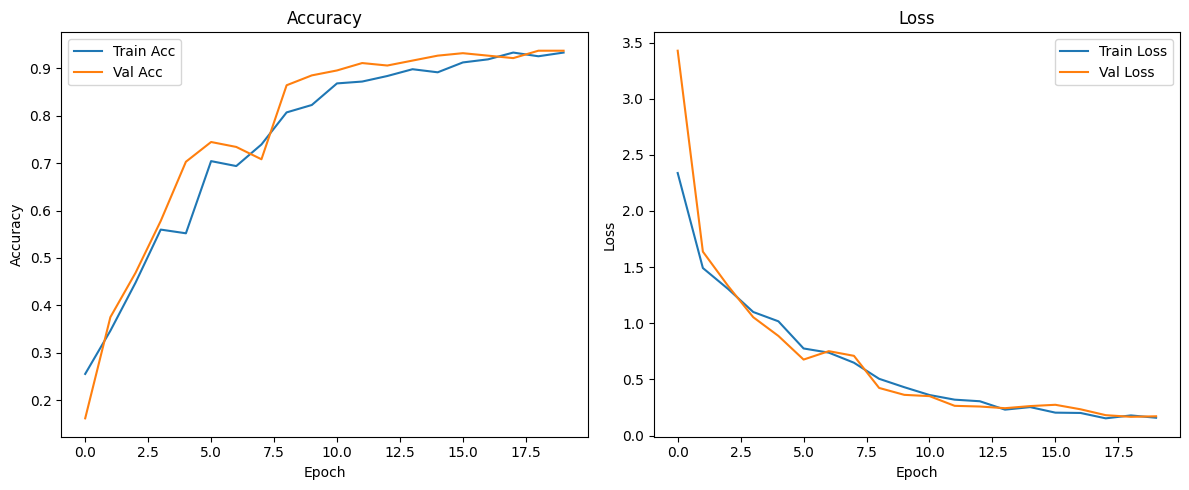

In [ ]:
# Fine-Tuned CNN for COPD Audio Classification (TensorFlow)

import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential, load_model 
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GaussianNoise
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping

# Step 1: Load labels
csv_path = "/home/punith/Desktop/cHEAL 2.o/balanced_labels.csv"
audio_dir = "/home/punith/Desktop/cHEAL 2.o/RespiratoryDatabase@TR"

labels_df = pd.read_csv(csv_path)
labels_df.columns = labels_df.columns.str.strip()
labels_dict = {label: idx for idx, label in enumerate(labels_df['Diagnosis'].unique())}

# Step 2: Extract MFCC
def extract_mfcc_image(file_path, max_len=150, augment=False):
    y, sr = librosa.load(file_path, sr=16000)
    if augment:
        if random.random() < 0.5:
            rate = random.uniform(0.9, 1.1)
            y = librosa.effects.time_stretch(y, rate=rate)
        else:
            steps = random.randint(-2, 2)
            y = librosa.effects.pitch_shift(y, sr=sr, n_steps=steps)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=20)
    if mfcc.shape[1] < max_len:
        pad_width = max_len - mfcc.shape[1]
        mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
    else:
        mfcc = mfcc[:, :max_len]
    return mfcc














# --- Step 3: Prepare dataset (CORRECTED & ROBUST) ---
X_list, y = [], []
for _, row in labels_df.iterrows():
    pid = str(row['Patient ID'])
    label = labels_dict[row['Diagnosis']]
    paths = [f for f in os.listdir(audio_dir) if f.startswith(pid) and f.endswith('.wav')]
    paths = [os.path.join(audio_dir, f) for f in paths]
    for fp in paths:
        if os.path.exists(fp):
            # We append the 2D MFCCs to a list first
            X_list.append(extract_mfcc_image(fp, augment=False))
            y.append(label)
            for _ in range(3):
                X_list.append(extract_mfcc_image(fp, augment=True))
                y.append(label)

# 1. Convert list of 2D MFCCs to a 3D numpy array
X_unnormalized = np.array(X_list)  # Shape: (samples, 20, 150)

# 2. Calculate the mean and std on the 3D array.
#    This correctly produces a mean/std of shape (20, 150)
mean_val = np.mean(X_unnormalized, axis=0)
std_val = np.std(X_unnormalized, axis=0)

# 3. Save these clean 2D arrays
print("Saving normalization statistics...")
np.save("mfcc_training_mean.npy", mean_val)
np.save("mfcc_training_std.npy", std_val)

# 4. Normalize the data using the calculated stats
X_normalized = (X_unnormalized - mean_val) / (std_val + 1e-6)

# 5. NOW, add the channel dimension for the CNN model
X = X_normalized[..., np.newaxis] # Final shape: (samples, 20, 150, 1)

# Continue with your label processing
y = np.array(y)
print(f"📊 Total audio samples: {len(X)}")
print(f"📊 Total labels: {len(y)}")
print(f"🧪 Unique classes: {np.unique(y, return_counts=True)}")
y_cat = to_categorical(y)

# Step 4: Compute class weights
y_int = np.argmax(y_cat, axis=1)
class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.2, stratify=y_cat, random_state=42)

# Step 6: Build model
from tensorflow.keras.regularizers import l2

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(20, 150, 1)),
    Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.35),
    Dense(48, activation='relu'),
    Dropout(0.2),  # increased dropout
    Dense(y_cat.shape[1], activation='softmax')
])

from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate=0.0012), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 7: Callbacks
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.4, patience=2, min_lr=1e-6, verbose=1)
model_checkpoint = ModelCheckpoint("best_copd_model_finetuned.h5", monitor='val_accuracy', save_best_only=True, verbose=1)

# Step 8: Train model
from tensorflow.keras.callbacks import Callback

class EpochCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        print(f"✅ Finished epoch {epoch+1} — val_acc: {logs['val_accuracy']:.4f}")

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_split=0.2,
    class_weight=class_weight_dict,
        callbacks=[lr_scheduler, model_checkpoint, EpochCallback()]  # re-added class weights
)

# Step 9: Evaluate
best_model = load_model("best_copd_model_finetuned.h5")
best_loss, best_acc = best_model.evaluate(X_test, y_test)
print(f"✅ Best Model Test Accuracy: {best_acc * 100:.2f}%")

from sklearn.metrics import classification_report

# Step 9.1: Classification report
y_true = np.argmax(y_test, axis=1)
y_pred = np.argmax(best_model.predict(X_test), axis=1)
print("🧾 Classification Report:")
print(classification_report(y_true, y_pred))

# Step 10: Plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# Compute classification report
report_dict = classification_report(y_true, y_pred, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T  # remove 'accuracy' row

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(report_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Classification Report Heatmap")
plt.ylabel("Classes")
plt.xlabel("Metrics")
plt.show()


NameError: name 'y_true' is not defined

New one for patient 104


In [ ]:
# # =========================================================================
# #
# #        Inference Script: Predict COPD Stage for a Single Audio File (Corrected)
# #
# # =========================================================================

# import os
# import librosa
# import numpy as np
# import pandas as pd
# from tensorflow.keras.models import load_model
# import warnings

# warnings.filterwarnings('ignore', category=UserWarning)

# # --- Step 1: Configuration ---
# MODEL_PATH = "best_copd_model_finetuned.h5"
# MEAN_PATH = "mfcc_training_mean.npy" # This will now be loaded as (20, 150)
# STD_PATH = "mfcc_training_std.npy"   # This will now be loaded as (20, 150)

# AUDIO_FILE_TO_PREDICT = "/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/104_1b1_Al_sc_Litt3200.wav"

# LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4']
# N_MFCC = 20
# MAX_LEN = 150

# def predict_copd_stage(audio_path):
#     print("--- Loading model and normalization stats... ---")
#     try:
#         model = load_model(MODEL_PATH)
#         training_mean = np.load(MEAN_PATH)
#         training_std = np.load(STD_PATH)
#         print("✅ Model and stats loaded successfully.")
#     except Exception as e:
#         print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
#         return

#     print(f"\n--- Processing audio file: {os.path.basename(audio_path)} ---")
#     try:
#         y, sr = librosa.load(audio_path, sr=16000)
#         mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC) # Shape: (20, t)
        
#         if mfcc.shape[1] < MAX_LEN:
#             mfcc = np.pad(mfcc, pad_width=((0,0), (0, MAX_LEN - mfcc.shape[1])), mode='constant')
#         else:
#             mfcc = mfcc[:, :MAX_LEN] # Shape is now (20, 150)
            
#         # THE FIX IN ACTION: The subtraction now works correctly.
#         # (20, 150) - (20, 150)
#         mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)

#         # Add batch and channel dimensions for the model's input
#         mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
        
#     except Exception as e:
#         print(f"❌ ERROR: Failed to process the audio file. Error: {e}")
#         return

#     print("\n--- Making prediction... ---")
#     try:
#         prediction_probs = model.predict(mfcc_final, verbose=0)[0]
#         predicted_class_index = np.argmax(prediction_probs)
#         predicted_class_name = LABELS[predicted_class_index]
#         confidence = prediction_probs[predicted_class_index]
#     except Exception as e:
#         print(f"❌ ERROR: Model failed to predict. Error: {e}")
#         return

#     print("\n" + "="*50); print("--- 🩺 Prediction Result ---")
#     print(f"The model predicts the diagnosis is: >> {predicted_class_name} <<")
#     print(f"Confidence: {confidence * 100:.2f}%")
#     print("="*50)
#     print("\nFull Probability Distribution:")
#     for i, prob in enumerate(prediction_probs):
#         print(f"  {LABELS[i]:<6}: {prob*100:.2f}%")

# if __name__ == "__main__":
#     if os.path.exists(AUDIO_FILE_TO_PREDICT):
#         predict_copd_stage(AUDIO_FILE_TO_PREDICT)
#     else:
#         print(f"❌ ERROR: Audio file not found at: {AUDIO_FILE_TO_PREDICT}")

--- Loading model and normalization stats... ---


✅ Model and stats loaded successfully.

--- Processing audio file: 104_1b1_Al_sc_Litt3200.wav ---

--- Making prediction... ---

--- 🩺 Prediction Result ---
The model predicts the diagnosis is: >> COPD4 <<
Confidence: 97.97%

Full Probability Distribution:
  COPD0 : 0.05%
  COPD1 : 0.02%
  COPD2 : 0.10%
  COPD3 : 1.87%
  COPD4 : 97.97%


In [56]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "104"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function ---
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---


✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 104 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 6 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 104_1b1_Al_sc_Litt3200.wav          | Predicted Stage: COPD4  | Confidence: 97.97%
  -> File: 104_1b1_Ar_sc_Litt3200.wav          | Predicted Stage: COPD4  | Confidence: 95.45%
  -> File: 104_1b1_Ll_sc_Litt3200.wav          | Predicted Stage: COPD4  | Confidence: 96.48%
  -> File: 104_1b1_Lr_sc_Litt3200.wav          | Predicted Stage: COPD2  | Confidence: 99.68%
  -> File: 104_1b1_Pl_sc_Litt3200.wav          | Predicted Stage: COPD3  | Confidence: 77.77%
  -> File: 104_1b1_Pr_sc_Litt3200.wav          | Predicted Stage: COPD4  | Confidence: 98.20%

--- 📋 Final Analysis for Patient 104 ---
Based on a majority vote of all 6 recordings, the most likely stage is:
    >> COPD4 <<
    (It received 4

Patient 114

In [57]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "114"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function ---
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---
✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 114 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 5 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 114_1b4_Al_mc_AKGC417L.wav          | Predicted Stage: COPD3  | Confidence: 99.98%
  -> File: 114_1b4_Ar_mc_AKGC417L.wav          | Predicted Stage: COPD1  | Confidence: 99.97%
  -> File: 114_1b4_Lr_mc_AKGC417L.wav          | Predicted Stage: COPD3  | Confidence: 93.10%
  -> File: 114_1b4_Pl_mc_AKGC417L.wav          | Predicted Stage: COPD3  | Confidence: 49.22%
  -> File: 114_1b4_Pr_mc_AKGC417L.wav          | Predicted Stage: COPD3  | Confidence: 95.87%

--- 📋 Final Analysis for Patient 114 ---
Based on a majority vote of all 5 recordings, the most likely stage is:
    >> COPD3 <<
    (It received 4 out of 5 votes, for a 80.00% consensus.)


Patient 142

In [58]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "142"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function ---
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---


✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 142 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 1 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 142_1b1_Pl_mc_LittC2SE.wav          | Predicted Stage: COPD3  | Confidence: 85.83%

--- 📋 Final Analysis for Patient 142 ---
Based on a majority vote of all 1 recordings, the most likely stage is:
    >> COPD3 <<
    (It received 1 out of 1 votes, for a 100.00% consensus.)


Patient 110


In [59]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "110"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function ---
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---


✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 110 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 5 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 110_1b1_Pr_sc_Meditron.wav          | Predicted Stage: COPD0  | Confidence: 48.99%
  -> File: 110_1p1_Al_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 99.59%
  -> File: 110_1p1_Ll_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 99.90%
  -> File: 110_1p1_Lr_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 93.44%
  -> File: 110_1p1_Pr_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 62.33%

--- 📋 Final Analysis for Patient 110 ---
Based on a majority vote of all 5 recordings, the most likely stage is:
    >> COPD4 <<
    (It received 4 out of 5 votes, for a 80.00% consensus.)


Patient 106

In [60]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "106"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function ---
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---


✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 106 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 2 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 106_2b1_Pl_mc_LittC2SE.wav          | Predicted Stage: COPD3  | Confidence: 99.75%
  -> File: 106_2b1_Pr_mc_LittC2SE.wav          | Predicted Stage: COPD4  | Confidence: 40.62%

--- 📋 Final Analysis for Patient 106 ---
Based on a majority vote of all 2 recordings, the most likely stage is:
    >> COPD3 <<
    (It received 1 out of 2 votes, for a 50.00% consensus.)


Patient 221

In [55]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "221"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function ---
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---


✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 221 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 12 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 221_2b1_Al_mc_LittC2SE.wav          | Predicted Stage: COPD1  | Confidence: 48.92%
  -> File: 221_2b1_Ar_mc_LittC2SE.wav          | Predicted Stage: COPD2  | Confidence: 45.99%
  -> File: 221_2b1_Lr_mc_LittC2SE.wav          | Predicted Stage: COPD1  | Confidence: 71.00%
  -> File: 221_2b1_Pl_mc_LittC2SE.wav          | Predicted Stage: COPD2  | Confidence: 67.47%
  -> File: 221_2b2_Al_mc_LittC2SE.wav          | Predicted Stage: COPD3  | Confidence: 40.32%
  -> File: 221_2b2_Ar_mc_LittC2SE.wav          | Predicted Stage: COPD2  | Confidence: 45.36%
  -> File: 221_2b2_Lr_mc_LittC2SE.wav          | Predicted Stage: COPD0  | Confidence: 79.80%
  -> File: 221_2b2_Pl_mc_LittC2SE.wav          | Pred

Patient 222

In [61]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "222"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function ---
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---
✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 222 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 3 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 222_1b1_Ar_sc_Meditron.wav          | Predicted Stage: COPD0  | Confidence: 97.97%
  -> File: 222_1b1_Lr_sc_Meditron.wav          | Predicted Stage: COPD0  | Confidence: 46.07%
  -> File: 222_1b1_Pr_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 50.01%

--- 📋 Final Analysis for Patient 222 ---
Based on a majority vote of all 3 recordings, the most likely stage is:
    >> COPD0 <<
    (It received 2 out of 3 votes, for a 66.67% consensus.)


Patient 223

In [ ]:
# =========================================================================
#
#       Patient Analysis Script: Predict COPD Stage for All Recordings
#
# This script loads your MFCC-based multi-class model and predicts the
# stage for every available recording of a specific patient.
#
# =========================================================================

import os
import librosa
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import warnings

# Suppress annoying librosa warnings
warnings.filterwarnings('ignore', category=UserWarning)

# --- Step 1: Configuration ---
# --- Files from your training run ---
MODEL_PATH = "best_copd_model_finetuned.h5"
MEAN_PATH = "mfcc_training_mean.npy"
STD_PATH = "mfcc_training_std.npy"

# --- The folder containing ALL new audio files ---
# This path should point to the directory shown in your screenshot
AUDIO_DIR = "./RespiratoryDatabase@TR"

# --- The Patient ID you want to analyze ---
# !!! UPDATE THIS TO THE PATIENT YOU WANT TO TEST (e.g., '221') !!!
PATIENT_ID_TO_ANALYZE = "223"

# --- Parameters that MUST match your training script ---
LABELS = ['COPD0', 'COPD1', 'COPD2', 'COPD3', 'COPD4'] # Must be in the correct order
N_MFCC = 20
MAX_LEN = 150

# --- Main Analysis Function ---
def analyze_patient_recordings(patient_id, audio_dir):
    """
    Finds all audio files for a given patient ID, processes each one,
    and reports the model's prediction for each.
    """
    # --- 1. Load Model and Normalization Statistics ---
    print("--- Loading model and normalization stats... ---")
    try:
        model = load_model(MODEL_PATH)
        training_mean = np.load(MEAN_PATH)
        training_std = np.load(STD_PATH)
        print("✅ Model and stats loaded successfully.")
    except Exception as e:
        print(f"❌ FATAL ERROR: Could not load required files. Error: {e}")
        return

    # --- 2. Find all audio files for the specified patient ---
    print(f"\n--- Searching for recordings for Patient ID: {patient_id} in '{audio_dir}' ---")
    
    # This logic finds all .wav files that start with the patient ID string
    patient_files = [os.path.join(audio_dir, f) for f in os.listdir(audio_dir)
                     if f.startswith(str(patient_id)) and f.endswith('.wav')]
    
    if not patient_files:
        print(f"❌ No .wav files found for Patient ID '{patient_id}'. Please check the ID and directory path.")
        return

    print(f"Found {len(patient_files)} audio files to analyze.")
    
    # --- 3. Loop through each file and predict ---
    print("\n--- 🩺 Individual Recording Predictions ---")
    all_predictions = []
    
    for file_path in sorted(patient_files): # sorted() makes the output tidy
        try:
            # a. Process the audio file into a normalized MFCC
            y, sr = librosa.load(file_path, sr=16000)
            mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
            if mfcc.shape[1] < MAX_LEN: mfcc = np.pad(mfcc, ((0,0), (0, MAX_LEN - mfcc.shape[1])))
            else: mfcc = mfcc[:, :MAX_LEN]
            mfcc_normalized = (mfcc - training_mean) / (training_std + 1e-6)
            mfcc_final = mfcc_normalized[np.newaxis, ..., np.newaxis]
            
            # b. Make prediction
            prediction_probs = model.predict(mfcc_final, verbose=0)[0]
            predicted_idx = np.argmax(prediction_probs)
            predicted_name = LABELS[predicted_idx]
            confidence = prediction_probs[predicted_idx]
            
            # c. Store and print the result for this file
            all_predictions.append(predicted_name)
            print(f"  -> File: {os.path.basename(file_path):<35} | Predicted Stage: {predicted_name:<6} | Confidence: {confidence*100:.2f}%")
            
        except Exception as e:
            print(f"  -> ERROR processing file {os.path.basename(file_path)}: {e}")

    # --- 4. Provide a final summary for the patient based on majority vote ---
    if all_predictions:
        final_verdict = max(set(all_predictions), key=all_predictions.count)
        vote_count = all_predictions.count(final_verdict)
        verdict_confidence = (vote_count / len(all_predictions)) * 100
        
        print("\n" + "="*50)
        print(f"--- 📋 Final Analysis for Patient {patient_id} ---")
        print(f"Based on a majority vote of all {len(all_predictions)} recordings, the most likely stage is:")
        print(f"    >> {final_verdict} <<")
        print(f"    (It received {vote_count} out of {len(all_predictions)} votes, for a {verdict_confidence:.2f}% consensus.)")
        print("="*50)

# --- Run the main analysis function --- 
if __name__ == "__main__":
    analyze_patient_recordings(PATIENT_ID_TO_ANALYZE, NEW_AUDIO_DIR)

--- Loading model and normalization stats... ---


✅ Model and stats loaded successfully.

--- Searching for recordings for Patient ID: 223 in '/home/punith/Desktop/cHEAL 2.o/archive/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files/' ---
Found 6 audio files to analyze.

--- 🩺 Individual Recording Predictions ---
  -> File: 223_1b1_Al_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 92.05%
  -> File: 223_1b1_Ar_sc_Meditron.wav          | Predicted Stage: COPD2  | Confidence: 72.51%
  -> File: 223_1b1_Ll_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 86.59%
  -> File: 223_1b1_Lr_sc_Meditron.wav          | Predicted Stage: COPD0  | Confidence: 34.45%
  -> File: 223_1b1_Pl_sc_Meditron.wav          | Predicted Stage: COPD4  | Confidence: 53.17%
  -> File: 223_1b1_Pr_sc_Meditron.wav          | Predicted Stage: COPD2  | Confidence: 71.64%

--- 📋 Final Analysis for Patient 223 ---
Based on a majority vote of all 6 recordings, the most likely stage is:
    >> COPD4 <<
    (It received 3